In [3]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import shap

In [5]:
dataset = pd.read_csv("hotel_bookings.csv")
df = dataset.copy()

In [9]:
df.shape
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [13]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [14]:
df.duplicated().sum()

np.int64(31994)

In [18]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum().sort_values(ascending=False)

company                           82137
agent                             12193
country                             452
children                              4
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
hotel                                 0
previous_cancellations                0
days_in_waiting_list                  0
customer_type                         0
adr                                   0
required_car_parking_spaces           0
total_of_special_requests             0
reservation_status                    0
previous_bookings_not_canceled        0
is_repeated_guest                     0
is_canceled                           0
distribution_channel                  0
market_segment                        0
meal                                  0
babies                                0
adults                                0
stays_in_week_nights                  0


In [20]:
df = df.drop(columns=["company"])
df["agent"] = df["agent"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["children"] = df["children"].fillna(df["children"].median())

In [21]:
df.isnull().sum().sort_values(ascending=False)

hotel                             0
is_repeated_guest                 0
reservation_status                0
total_of_special_requests         0
required_car_parking_spaces       0
adr                               0
customer_type                     0
days_in_waiting_list              0
agent                             0
deposit_type                      0
booking_changes                   0
assigned_room_type                0
reserved_room_type                0
previous_bookings_not_canceled    0
previous_cancellations            0
distribution_channel              0
is_canceled                       0
market_segment                    0
country                           0
meal                              0
babies                            0
children                          0
adults                            0
stays_in_week_nights              0
stays_in_weekend_nights           0
arrival_date_day_of_month         0
arrival_date_week_number          0
arrival_date_month          

# EDA

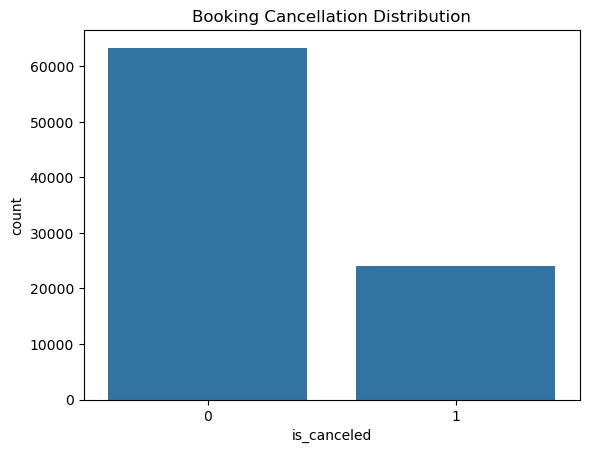

In [22]:
df["is_canceled"].value_counts()
sns.countplot(x="is_canceled", data=df)
plt.title("Booking Cancellation Distribution")
plt.show()

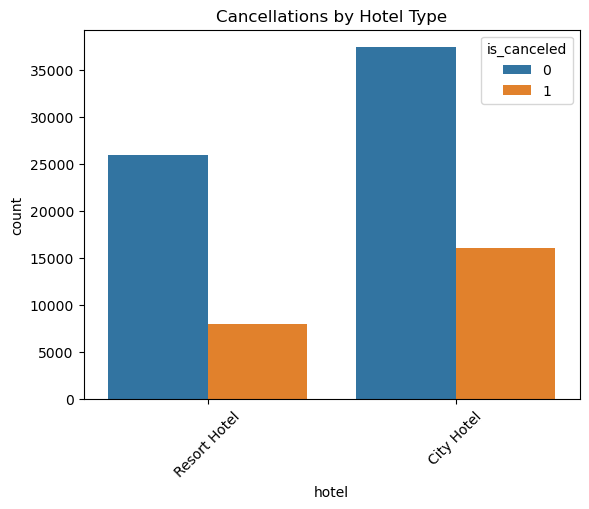

In [23]:
sns.countplot(x="hotel", hue="is_canceled", data=df)
plt.title("Cancellations by Hotel Type")
plt.xticks(rotation=45)
plt.show()

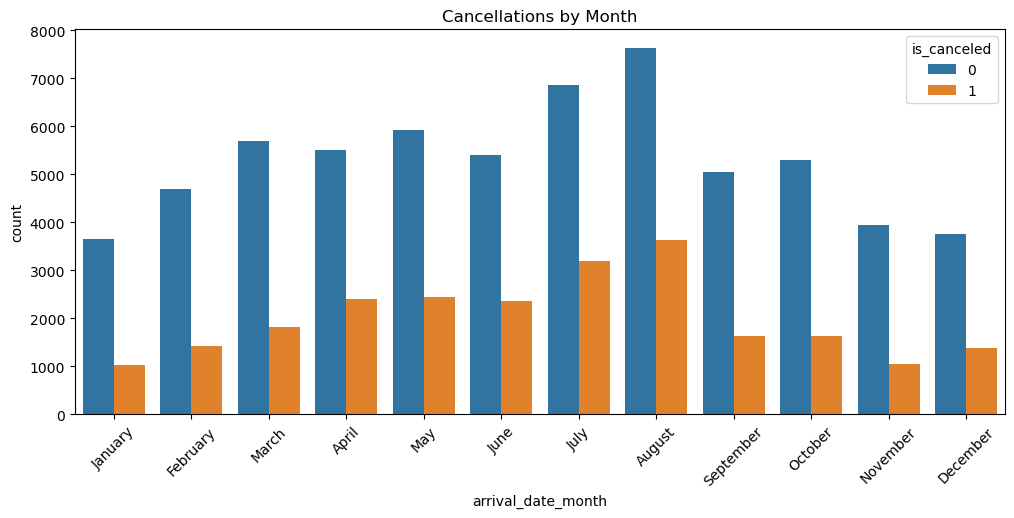

In [24]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="arrival_date_month",
    hue="is_canceled",
    data=df,
    order=[
        "January","February","March","April","May","June",
        "July","August","September","October","November","December"
    ]
)

plt.xticks(rotation=45)
plt.title("Cancellations by Month")
plt.show()

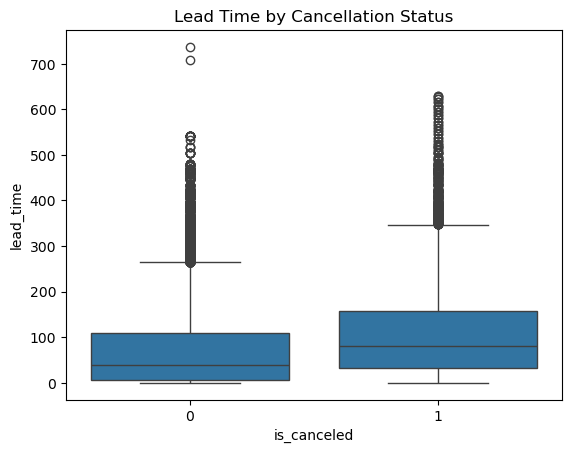

In [25]:
sns.boxplot(x="is_canceled", y="lead_time", data=df)
plt.title("Lead Time by Cancellation Status")
plt.show()

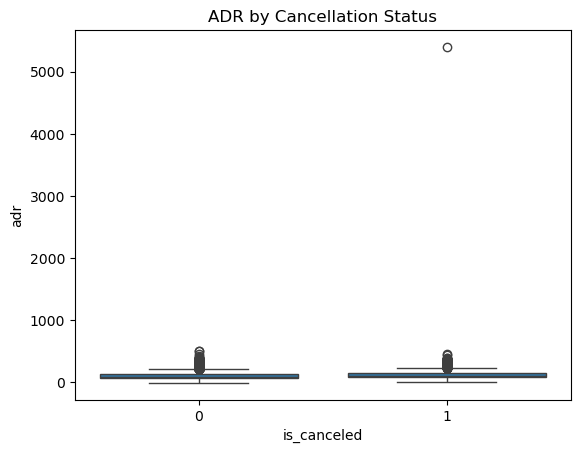

In [26]:
sns.boxplot(x="is_canceled", y="adr", data=df)
plt.title("ADR by Cancellation Status")
plt.show()

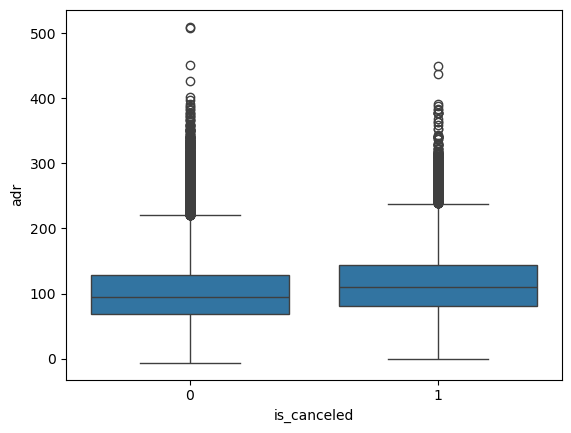

In [27]:
df = df[df["adr"] < 1000]
sns.boxplot(x="is_canceled", y="adr", data=df)
plt.show()

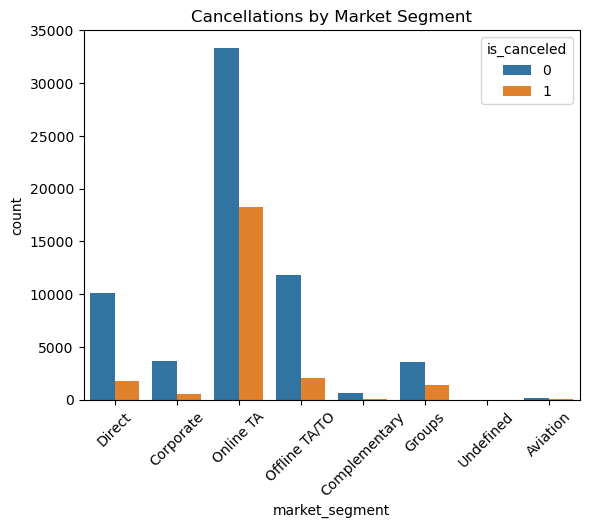

In [28]:
sns.countplot(x="market_segment", hue="is_canceled", data=df)
plt.xticks(rotation=45)
plt.title("Cancellations by Market Segment")
plt.show()

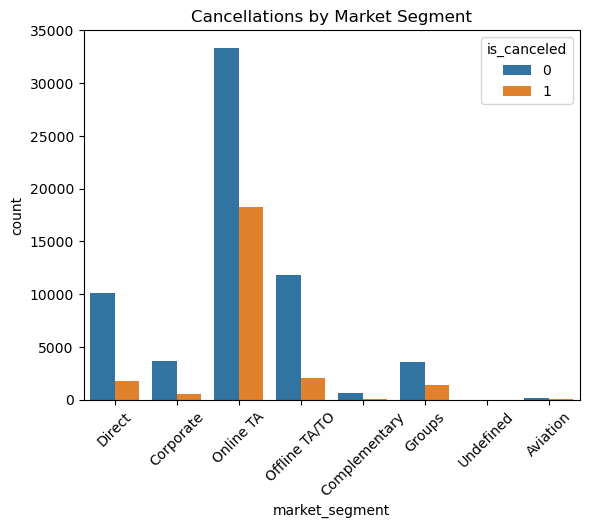

In [29]:
sns.countplot(x="market_segment", hue="is_canceled", data=df)
plt.xticks(rotation=45)
plt.title("Cancellations by Market Segment")
plt.show()

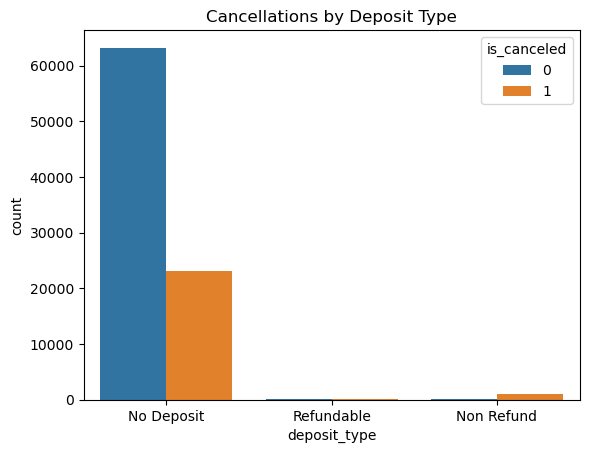

In [30]:
sns.countplot(x="deposit_type", hue="is_canceled", data=df)
plt.title("Cancellations by Deposit Type")
plt.show()

# outliers

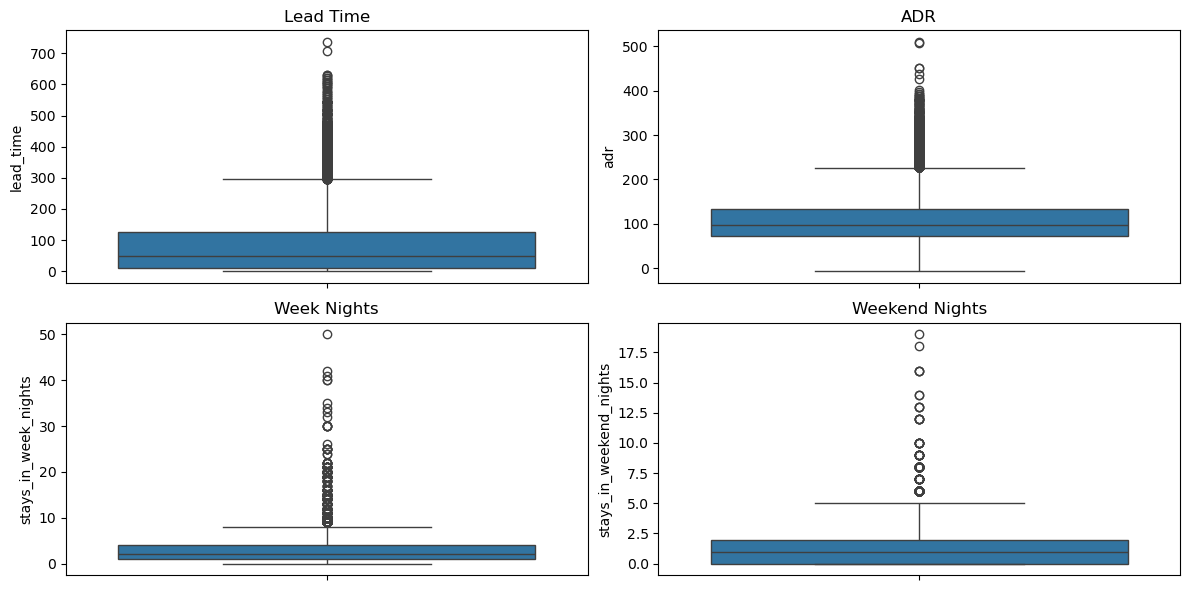

In [31]:
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
sns.boxplot(y=df["lead_time"])
plt.title("Lead Time")

plt.subplot(2,2,2)
sns.boxplot(y=df["adr"])
plt.title("ADR")

plt.subplot(2,2,3)
sns.boxplot(y=df["stays_in_week_nights"])
plt.title("Week Nights")

plt.subplot(2,2,4)
sns.boxplot(y=df["stays_in_weekend_nights"])
plt.title("Weekend Nights")

plt.tight_layout()
plt.show()

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87395 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87395 non-null  object 
 1   is_canceled                     87395 non-null  int64  
 2   lead_time                       87395 non-null  int64  
 3   arrival_date_year               87395 non-null  int64  
 4   arrival_date_month              87395 non-null  object 
 5   arrival_date_week_number        87395 non-null  int64  
 6   arrival_date_day_of_month       87395 non-null  int64  
 7   stays_in_weekend_nights         87395 non-null  int64  
 8   stays_in_week_nights            87395 non-null  int64  
 9   adults                          87395 non-null  int64  
 10  children                        87395 non-null  float64
 11  babies                          87395 non-null  int64  
 12  meal                            8739

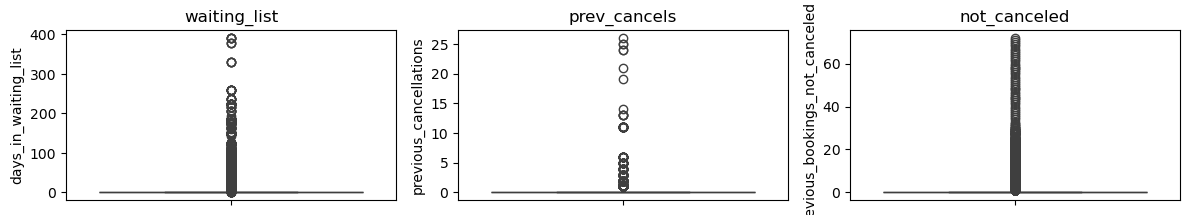

In [37]:
plt.figure(figsize=(12,6))

plt.subplot(3,3,1)
sns.boxplot(y=df["days_in_waiting_list"])
plt.title("waiting_list")

plt.subplot(3,3,2)
sns.boxplot(y=df["previous_cancellations"])
plt.title("prev_cancels")

plt.subplot(3,3,3)
sns.boxplot(y=df["previous_bookings_not_canceled"])
plt.title("not_canceled")

plt.tight_layout()
plt.show()

# outliers

In [38]:
df = df[df["adr"] < 500]
df["lead_time"] = np.where(df["lead_time"] > 365, 365, df["lead_time"])
df["stays_in_week_nights"] = np.where(
    df["stays_in_week_nights"] > 30, 
    30, 
    df["stays_in_week_nights"]
)
df["stays_in_weekend_nights"] = np.where(
    df["stays_in_weekend_nights"] > 10, 
    10, 
    df["stays_in_weekend_nights"]
)

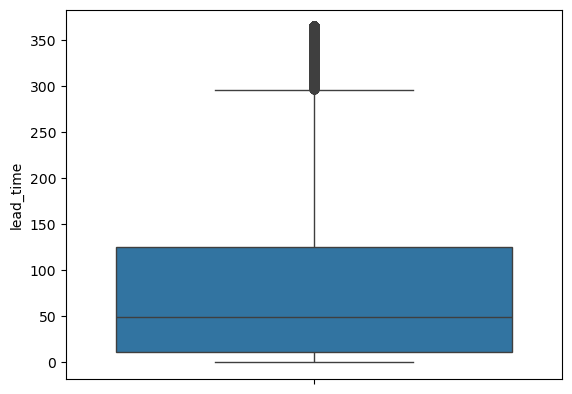

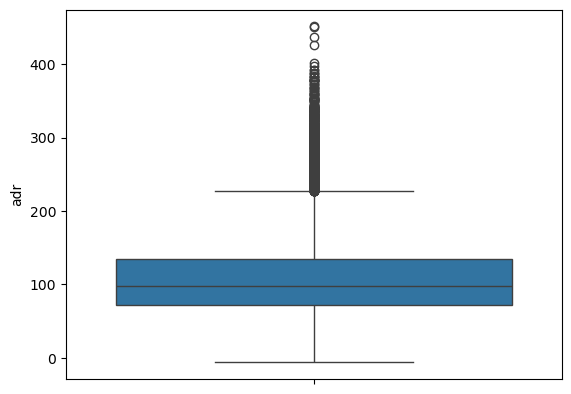

In [39]:
sns.boxplot(y=df["lead_time"])
plt.show()

sns.boxplot(y=df["adr"])
plt.show()

# feature engineering

In [41]:
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["is_family"] = np.where(df["total_guests"] > 2, 1, 0)
df["guests_per_night"] = df["total_guests"] / (df["total_nights"] + 1)

In [42]:
def get_season(month):
    if month in ["December","January","February"]:
        return "Winter"
    elif month in ["March","April","May"]:
        return "Spring"
    elif month in ["June","July","August"]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["arrival_date_month"].apply(get_season)

In [43]:
df[[
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_nights",
    "total_guests",
    "is_family",
    "guests_per_night"
]].head()

,stays_in_weekend_nights,stays_in_week_nights,total_nights,total_guests,is_family,guests_per_night
0,0,0,0,2.0,0,2.000000
1,0,0,0,2.0,0,2.000000
2,0,1,1,1.0,0,0.500000
3,0,1,1,1.0,0,0.500000
4,0,2,2,2.0,0,0.666667


# table split for dashboard

In [44]:
df["booking_id"] = range(len(df))

In [45]:
booking_df = df[[
    "booking_id",
    "hotel",
    "lead_time",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "total_nights",
    "adr"
]]

customer_df = df[[
    "booking_id",
    "adults",
    "children",
    "babies",
    "total_guests",
    "is_family",
    "country",
    "customer_type"
]]

reservation_df = df[[
    "booking_id",
    "is_canceled",
    "deposit_type",
    "market_segment",
    "distribution_channel",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "guests_per_night",
    "season"
]]

In [46]:
booking_df.to_csv("booking.csv", index=False)
customer_df.to_csv("customer.csv", index=False)
reservation_df.to_csv("reservation.csv", index=False)

In [47]:
print(df["booking_id"])

0             0
1             1
2             2
3             3
4             4
          ...  
119385    87388
119386    87389
119387    87390
119388    87391
119389    87392
Name: booking_id, Length: 87393, dtype: int64


# preprocessing

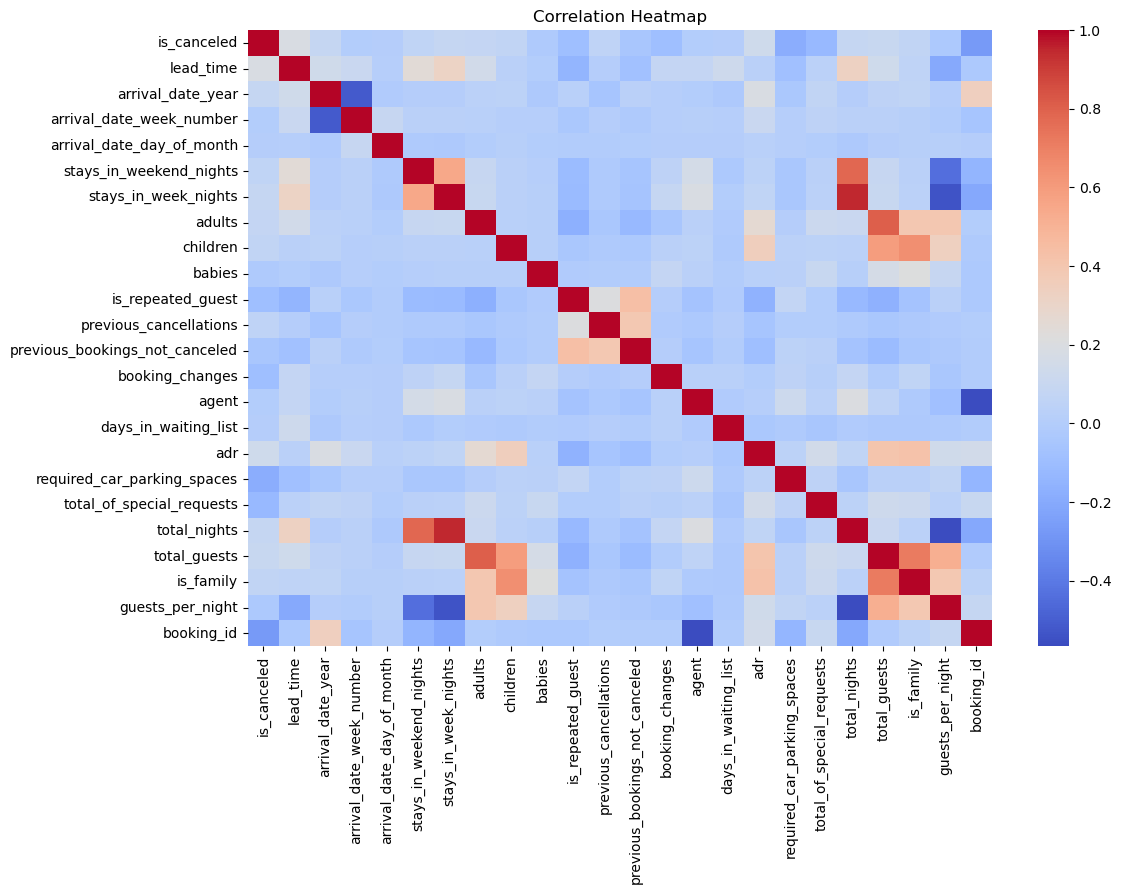

In [48]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap")
plt.show()

In [49]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_nights',
       'total_guests', 'is_family', 'guests_per_night', 'season',
       'booking_id'],
      dtype='object')

In [50]:
X = df.drop([
    "is_canceled",
    "booking_id",
    "reservation_status",
    "reservation_status_date",
    "agent"
], axis=1)

y = df["is_canceled"]


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

In [53]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [54]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# ML

In [55]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [56]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7933520224269123
Precision: 0.6707701116518752
Recall: 0.48761706555671175
F1 Score: 0.5647143890093999


In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86     12674
           1       0.67      0.49      0.56      4805

    accuracy                           0.79     17479
   macro avg       0.75      0.70      0.71     17479
weighted avg       0.78      0.79      0.78     17479



In [58]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [59]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.8402654614108359
Precision: 0.7693336901257694
Recall: 0.5983350676378772
F1 Score: 0.6731444626551158
              precision    recall  f1-score   support

           0       0.86      0.93      0.89     12674
           1       0.77      0.60      0.67      4805

    accuracy                           0.84     17479
   macro avg       0.81      0.77      0.78     17479
weighted avg       0.83      0.84      0.83     17479



In [60]:
from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [61]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Accuracy: 0.8424394988271641
Precision: 0.7442248154322457
Recall: 0.6503642039542143
F1 Score: 0.6941359395824078
              precision    recall  f1-score   support

           0       0.87      0.92      0.89     12674
           1       0.74      0.65      0.69      4805

    accuracy                           0.84     17479
   macro avg       0.81      0.78      0.79     17479
weighted avg       0.84      0.84      0.84     17479



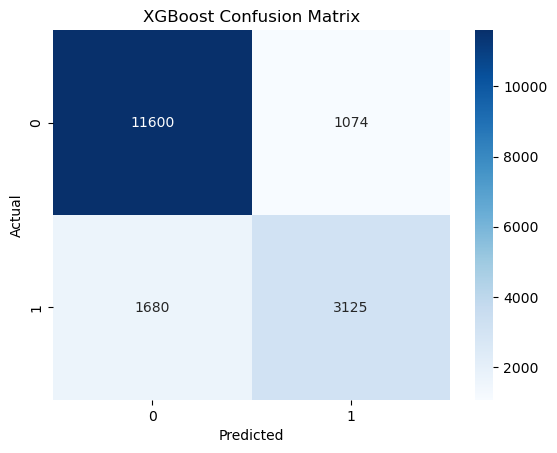

In [62]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [63]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,XGBoost,0.842439,0.744225,0.650364,0.694136
1,Random Forest,0.840265,0.769334,0.598335,0.673144
0,Logistic Regression,0.793352,0.670770,0.487617,0.564714


# SHAP

In [66]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()


In [67]:
encoded_cat_names = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_cols)
all_feature_names = list(numeric_cols) + list(encoded_cat_names)

X_train_shap_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_shap_df = pd.DataFrame(X_test_processed, columns=all_feature_names)

 99%|===================| 17290/17479 [00:33<00:00]        

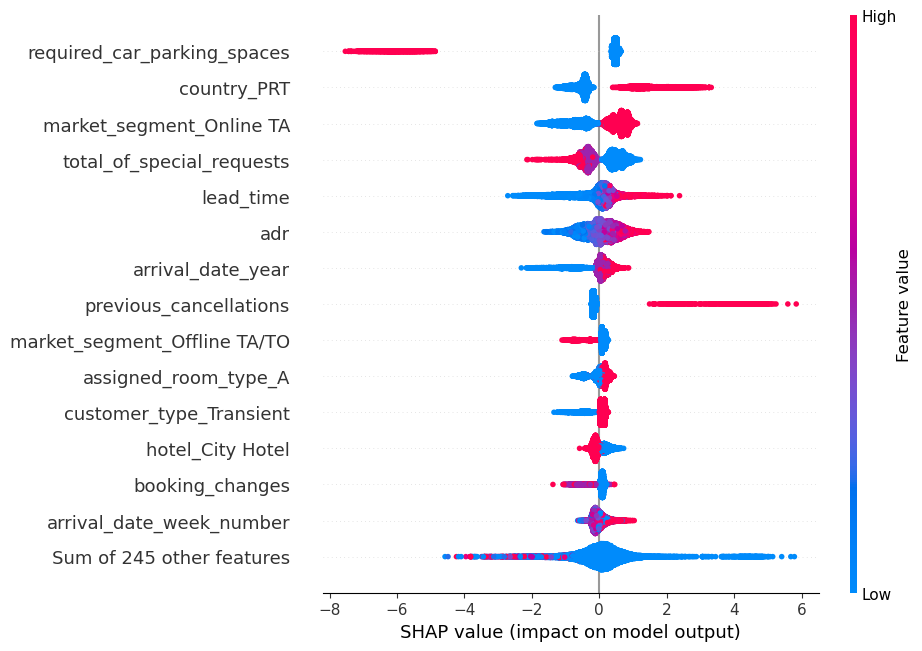

In [69]:
final_xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

final_xgb.fit(X_train_shap_df, y_train)

explainer = shap.Explainer(final_xgb, X_train_shap_df)
shap_values = explainer(X_test_shap_df)

shap.plots.beeswarm(shap_values, max_display=15)

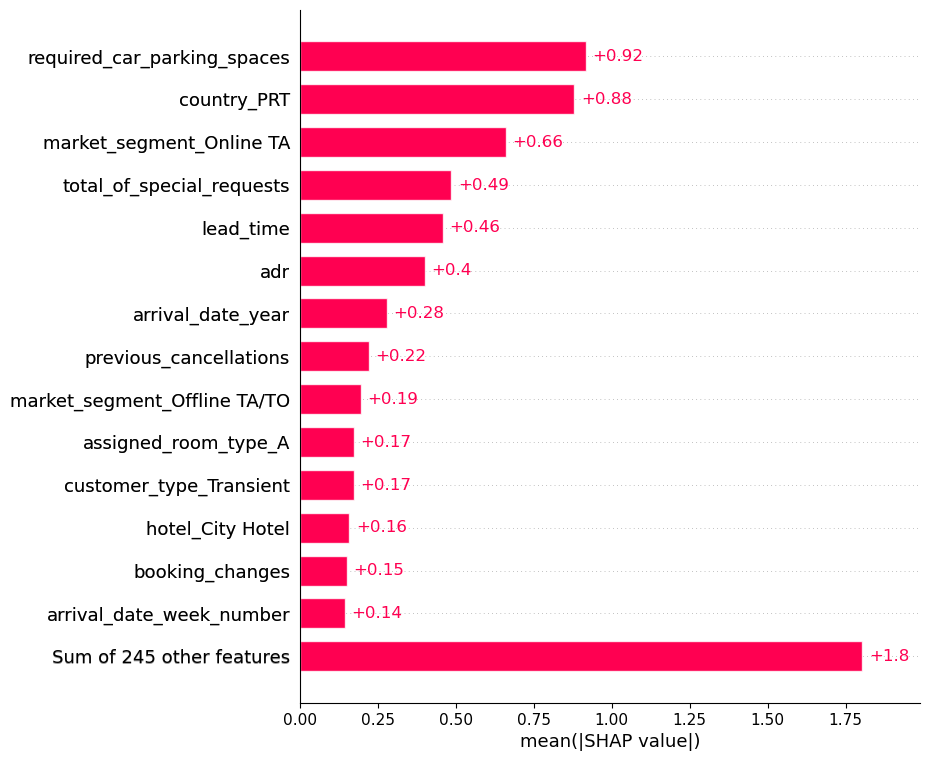

In [70]:
shap.plots.bar(shap_values, max_display=15)

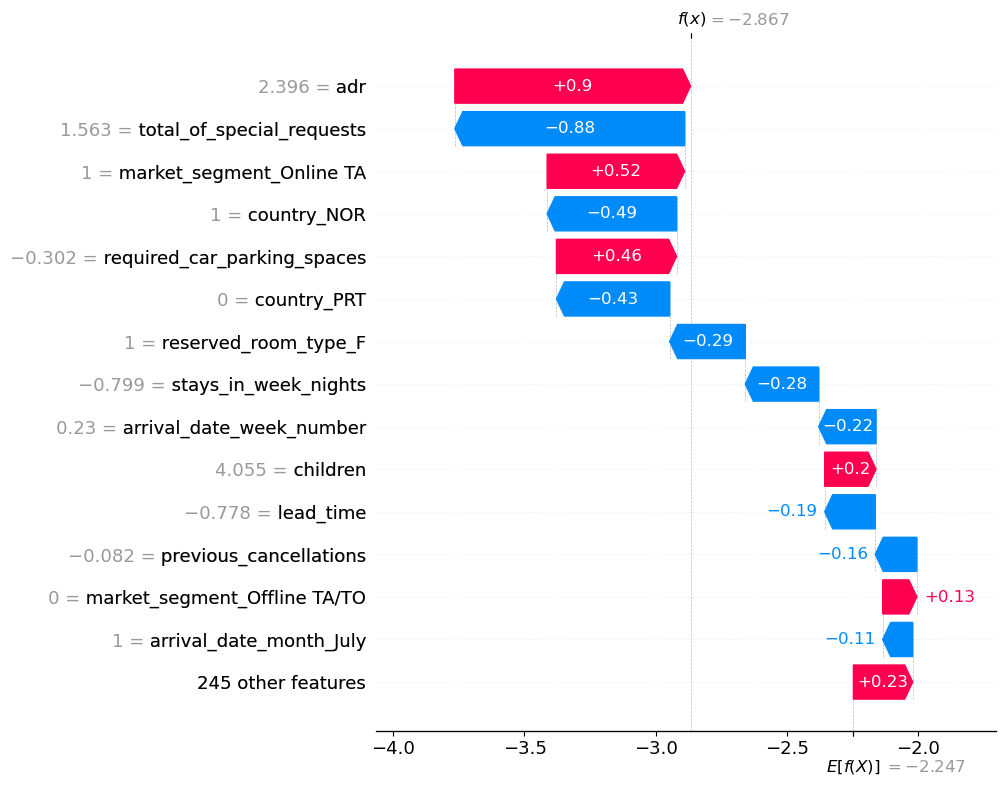

In [71]:
shap.plots.waterfall(shap_values[0], max_display=15)

# bias analysis

In [72]:
# Use the already trained xgb_model pipeline
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [73]:
bias_df = X_test.copy()
bias_df["actual"] = y_test.values
bias_df["predicted"] = xgb_pred
bias_df["probability"] = xgb_prob

In [76]:
def group_bias_analysis(df, group_col):
    results = []

    for group_value in df[group_col].dropna().unique():
        subset = df[df[group_col] == group_value]

        if len(subset) == 0:
            continue

        results.append({
            "group": group_value,
            "count": len(subset),
            "accuracy": accuracy_score(subset["actual"], subset["predicted"]),
            "precision": precision_score(subset["actual"], subset["predicted"], zero_division=0),
            "recall": recall_score(subset["actual"], subset["predicted"], zero_division=0),
            "f1_score": f1_score(subset["actual"], subset["predicted"], zero_division=0)
        })

    return pd.DataFrame(results).sort_values(by="f1_score", ascending=False)

In [77]:
hotel_bias = group_bias_analysis(bias_df, "hotel")
customer_bias = group_bias_analysis(bias_df, "customer_type")
segment_bias = group_bias_analysis(bias_df, "market_segment")

In [81]:
print("hotel bias: ", hotel_bias)
print("customer bias: ",customer_bias)
print("segment bias: ", segment_bias)


hotel bias:            group  count  accuracy  precision    recall  f1_score
1  Resort Hotel   6889  0.880970   0.759762  0.715265  0.736842
0    City Hotel  10590  0.817375   0.735491  0.617812  0.671535
customer bias:               group  count  accuracy  precision    recall  f1_score
3            Group    120  0.966667   0.875000  0.700000  0.777778
1         Contract    614  0.934853   0.758621  0.776471  0.767442
0        Transient  14411  0.827770   0.742247  0.656070  0.696503
2  Transient-Party   2334  0.902314   0.764045  0.552846  0.641509
segment bias:             group  count  accuracy  precision    recall  f1_score
4         Groups   1000  0.931000   0.903704  0.850174  0.876122
2  Offline TA/TO   2772  0.922078   0.786517  0.666667  0.721649
0      Online TA  10328  0.800058   0.731627  0.678907  0.704282
1         Direct   2372  0.880691   0.704698  0.305233  0.425963
3      Corporate    843  0.889680   0.611111  0.314286  0.415094
6  Complementary    120  0.858333   0.5

In [82]:
import joblib

joblib.dump(final_xgb, "xgboost_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [83]:
import pandas as pd
import joblib

model = joblib.load("xgboost_model.pkl")
preprocessor = joblib.load("preprocessor.pkl")

def score_new_data(input_df):
    input_df = input_df.copy()

    cols_to_drop = ["is_canceled", "booking_id", "reservation_status", "reservation_status_date", "agent"]
    input_df = input_df.drop(columns=[col for col in cols_to_drop if col in input_df.columns], errors="ignore")

    processed = preprocessor.transform(input_df)

    if hasattr(processed, "toarray"):
        processed = processed.toarray()

    input_df["predicted_is_canceled"] = model.predict(processed)
    input_df["cancellation_probability"] = model.predict_proba(processed)[:, 1]

    return input_df

In [84]:
sample_batch = X_test.iloc[:5]
score_new_data(sample_batch)

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,is_family,guests_per_night,season,predicted_is_canceled,cancellation_probability
93429,City Hotel,14,2016,July,30,21,0,1,2,2.0,...,231.0,0,2,1,4.0,1,2.000000,Summer,0,0.053790
115577,City Hotel,8,2017,July,27,7,0,1,1,0.0,...,140.0,0,0,1,1.0,0,0.500000,Summer,0,0.301042
39234,Resort Hotel,190,2017,August,31,2,2,8,2,0.0,...,161.4,0,0,10,2.0,0,0.181818,Summer,0,0.010041
63268,City Hotel,146,2017,February,5,4,2,1,2,0.0,...,93.6,0,0,3,2.0,0,0.500000,Winter,1,0.912175
90939,City Hotel,18,2016,June,25,12,2,0,2,1.0,...,129.0,0,0,2,3.0,1,1.000000,Summer,0,0.340015
